In [2]:
import pandas as pd
import numpy as np

# Load the datasets
weather_df = pd.read_csv('SriLanka_Weather_Dataset.csv')
location_df = pd.read_csv('sri_lanka_heritage_1000 (3).csv')

print("\nWEATHER DATASET COLUMNS:")
for i, col in enumerate(weather_df.columns, 1):
    print(f"{i}. {col}")

print("\nLOCATION DATASET COLUMNS:")
for i, col in enumerate(location_df.columns, 1):
    print(f"{i}. {col}")


# Show dataset shapes
print("\nDATASET INFORMATION:")
print(f"Weather dataset shape: {weather_df.shape} (rows, columns)")
print(f"Location dataset shape: {location_df.shape} (rows, columns)")


WEATHER DATASET COLUMNS:
1. time
2. weathercode
3. temperature_2m_max
4. temperature_2m_min
5. temperature_2m_mean
6. apparent_temperature_max
7. apparent_temperature_min
8. apparent_temperature_mean
9. sunrise
10. sunset
11. shortwave_radiation_sum
12. precipitation_sum
13. rain_sum
14. snowfall_sum
15. precipitation_hours
16. windspeed_10m_max
17. windgusts_10m_max
18. winddirection_10m_dominant
19. et0_fao_evapotranspiration
20. latitude
21. longitude
22. elevation
23. country
24. city

LOCATION DATASET COLUMNS:
1. name
2. address
3. lat
4. lng
5. rating
6. types
7. reviews
8. photos
9. description
10. district
11. keyword

DATASET INFORMATION:
Weather dataset shape: (147480, 24) (rows, columns)
Location dataset shape: (941, 11) (rows, columns)


In [3]:
import pandas as pd
import numpy as np

weather = pd.read_csv('SriLanka_Weather_Dataset.csv')
location= pd.read_csv('sri_lanka_heritage_1000 (3).csv')


weather_drop_cols = [
    'country',
    'et0_fao_evapotranspiration',
    'snowfall_sum',
    'shortwave_radiation_sum'
]

weather = weather.drop(columns=weather_drop_cols)

location_drop_cols = [
    'rating',
    'types',
    'reviews',
    'photos'
]

location = location.drop(columns=location_drop_cols)

weather['time'] = pd.to_datetime(weather['time'])

weather = weather.rename(columns={
    'latitude': 'station_lat',
    'longitude': 'station_lng'
})

location = location.rename(columns={
    'lat': 'location_lat',
    'lng': 'location_lng'
})

# Fill numeric missing values with column mean
num_cols_weather = weather.select_dtypes(include='number').columns
weather[num_cols_weather] = weather[num_cols_weather].fillna(
    weather[num_cols_weather].mean()
)

import numpy as np

def haversine(lat1, lon1, lat2, lon2):
    R = 6371  # Earth radius in km
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = np.sin(dlat / 2) ** 2 + \
        np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2

    c = 2 * np.arcsin(np.sqrt(a))
    return R * c


stations = weather[['station_lat', 'station_lng', 'city', 'elevation']].drop_duplicates().reset_index(drop=True)

nearest_station_list = []

for _, loc in location.iterrows():
    distances = haversine(
        loc['location_lat'],
        loc['location_lng'],
        stations['station_lat'],
        stations['station_lng']
    )

    nearest_idx = distances.idxmin()
    nearest_station = stations.loc[nearest_idx]

    nearest_station_list.append({
        'name': loc['name'],
        'address': loc['address'],
        'district': loc['district'],
        'keyword': loc['keyword'],
        'location_lat': loc['location_lat'],
        'location_lng': loc['location_lng'],
        'station_lat': nearest_station['station_lat'],
        'station_lng': nearest_station['station_lng'],
        'city': nearest_station['city'],
        'elevation': nearest_station['elevation'],
        'distance_km': distances.min()
    })

location_station_map = pd.DataFrame(nearest_station_list)

final_df = pd.merge(
    weather,
    location_station_map,
    on=['station_lat', 'station_lng'],
    how='inner'
)

final_df.to_csv('final_weather_location_dataset.csv', index=False)

print(final_df.shape)
final_df.head()





(5786132, 29)


,time,weathercode,temperature_2m_max,temperature_2m_min,temperature_2m_mean,apparent_temperature_max,apparent_temperature_min,apparent_temperature_mean,sunrise,sunset,...,city_x,name,address,district,keyword,location_lat,location_lng,city_y,elevation_y,distance_km
0,2010-01-01,2,30.0,22.7,26.1,34.4,25.2,29.2,2010-01-01T00:52,2010-01-01T12:35,...,Colombo,Maha Kali Amman Temple,"Kimbulawala, XV88XQ6, Colombo, Sri Lanka",Colombo,ancient temple,6.967414,79.866898,Colombo,16.0,5.145086
1,2010-01-01,2,30.0,22.7,26.1,34.4,25.2,29.2,2010-01-01T00:52,2010-01-01T12:35,...,Colombo,Hindu Temple Murugan Kovil,"XVMH5CM, Wattala, Sri Lanka",Colombo,hindu kovil,6.982959,79.878540,Colombo,16.0,3.032693
2,2010-01-01,2,30.0,22.7,26.1,34.4,25.2,29.2,2010-01-01T00:52,2010-01-01T12:35,...,Colombo,Iyngaran Pillayar Kovil,"01300 Kotahena St, Colombo 01300, Sri Lanka",Colombo,hindu kovil,6.950052,79.862770,Colombo,16.0,6.908412
3,2010-01-01,2,30.0,22.7,26.1,34.4,25.2,29.2,2010-01-01T00:52,2010-01-01T12:35,...,Colombo,Sri Ananda Aiyappan Temple,"XV58QC2, Colombo, Sri Lanka",Colombo,hindu kovil,6.959395,79.866013,Colombo,16.0,5.869624
4,2010-01-01,2,30.0,22.7,26.1,34.4,25.2,29.2,2010-01-01T00:52,2010-01-01T12:35,...,Colombo,Mukadam Shivan Temple,"XV88VMH, Temple Rd, Colombo, Sri Lanka",Colombo,hindu kovil,6.967182,79.866729,Colombo,16.0,5.176515


In [ ]:
import pandas as pd

# Load final dataset
df = pd.read_csv('final_weather_location_dataset.csv')

# Columns to KEEP (method + tourism focused)
columns_to_keep = [
    # Methodology (nearest station linking)
    'station_lat',
    'station_lng',
    'distance_km',

    # Time
    'time',

    # Temperature (tourist-relevant)
    'temperature_2m_max',
    'temperature_2m_min',
    'temperature_2m_mean',

    # Weather comfort
    'apparent_temperature_mean',
    'weathercode',

    # Rain & precipitation
    'precipitation_sum',
    'rain_sum',
    'precipitation_hours',

    # Wind
    'windspeed_10m_max',

    # Day planning
    'sunrise',
    'sunset',

    # Location info
    'name',
    'address',
    'district',
    'keyword',
    'location_lat',
    'location_lng',

    # Reference climate info
    'city_x',
    'elevation_x'
]

# Keep only these columns
df_clean = df[columns_to_keep]

print("Final columns:")
print(df_clean.columns.tolist())
print("Final shape:", df_clean.shape)

# Save cleaned dataset
df_clean.to_csv('final_weather_location_tourism_ready.csv', index=False)


LOADING AND PREPARING DATA
Original dataset shape: (5786132, 23)
Date range: 2010-01-01 00:00:00 to 2023-06-17 00:00:00
Number of unique locations: 925
Number of unique weather stations: 30

FEATURE ENGINEERING
Enhanced dataset shape: (5786132, 50)
Number of features created: 50

PREPARING DATA FOR MODELING
Number of numeric features: 29
Features: ['distance_km', 'temperature_2m_max', 'temperature_2m_min', 'apparent_temperature_mean', 'weathercode', 'rain_sum', 'precipitation_hours', 'hour', 'is_weekend', 'month_sin']...

Training data: 2010-01-01 00:00:00 to 2020-10-06 00:00:00
Testing data: 2020-10-07 00:00:00 to 2023-06-17 00:00:00
Train shape: (4627964, 50), Test shape: (1158168, 50)

TRAINING LIGHTGBM MODELS

Training model for: temperature_2m_mean
[100]	train's rmse: 0.138719
[200]	train's rmse: 0.105121
[300]	train's rmse: 0.0880665
[400]	train's rmse: 0.0764324
[500]	train's rmse: 0.0680967
  RMSE: 0.0813
  MAE:  0.0601
  R2:   0.9985

Training model for: precipitation_sum
[100

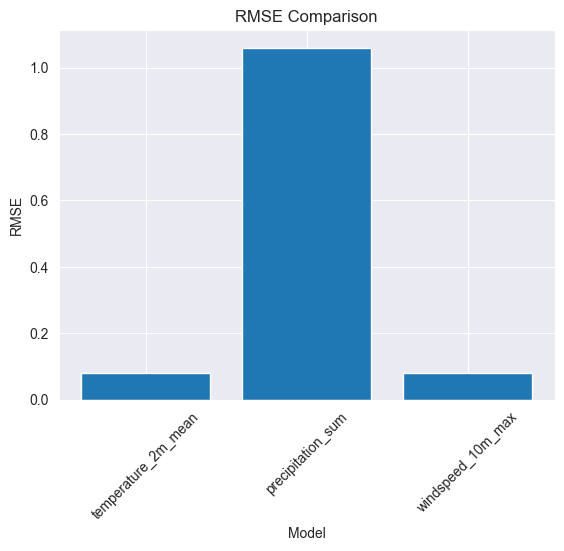

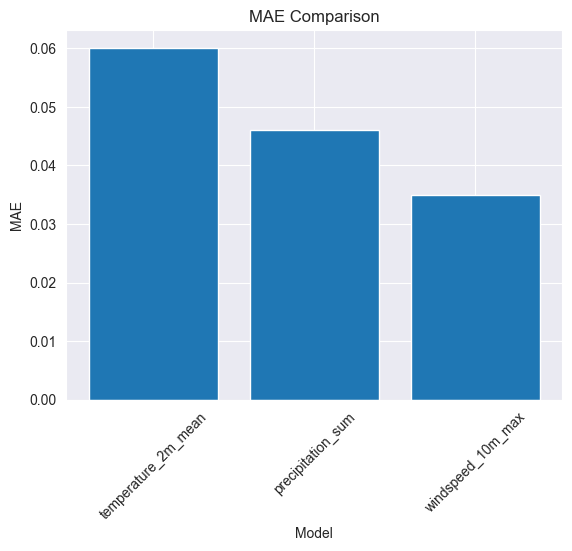

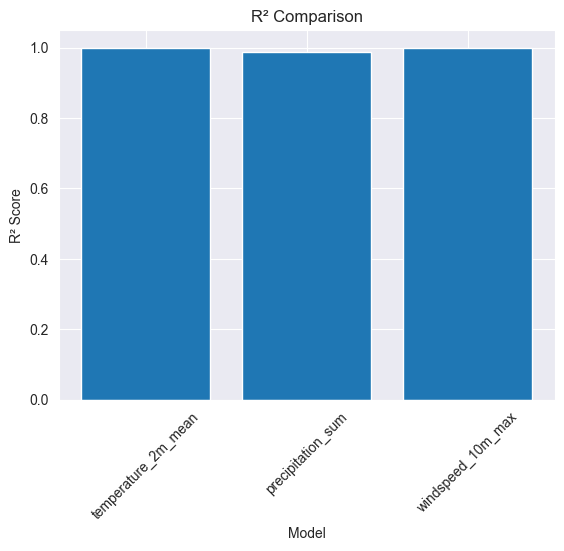


Top 15 Most Important Features (Temperature Model):
                  feature  importance
apparent_temperature_mean        3356
            apparent_diff        2758
           temp_rolling_3        1874
               temp_lag_1        1457
       temperature_2m_max        1045
       temperature_2m_min        1006
           temp_rolling_7         728
                 rain_sum         428
                 wind_log         341
               temp_range         278
           rain_intensity         234
               rain_lag_1         226
      precipitation_hours         174
           wind_rolling_3         162
             city_encoded         153

WEATHER PREDICTION FUNCTION

DEMO: PREDICT WEATHER FOR A LOCATION

Predicting weather for: #NAME?
Target date: 2026-03-09

 WEATHER PREDICTION:
   Temperature: 29.06°C
   Precipitation: 0.0 mm
   Wind Speed: 28.71 km/h

SAVING MODELS FOR FUTURE USE
✓ Saved model: lightgbm_model_temperature_2m_mean.txt
✓ Saved model: lightgbm_model_preci

In [1]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)

# 1. LOAD AND PREPARE DATA
print("="*50)
print("LOADING AND PREPARING DATA")
print("="*50)

# Load the dataset
df = pd.read_csv('final_weather_location_tourism_ready.csv')

# Convert time to datetime
df['time'] = pd.to_datetime(df['time'])

# Sort by time
df = df.sort_values('time').reset_index(drop=True)

print(f"Original dataset shape: {df.shape}")
print(f"Date range: {df['time'].min()} to {df['time'].max()}")
print(f"Number of unique locations: {df['name'].nunique()}")
print(f"Number of unique weather stations: {df['city_x'].nunique()}")

# 2. FEATURE ENGINEERING
print("\n" + "="*50)
print("FEATURE ENGINEERING")
print("="*50)

def create_features(df):
    """Create time-based and weather-based features"""
    df_feat = df.copy()

    # TIME-BASED FEATURES
    df_feat['hour'] = 12  # Default hour since only have daily data
    df_feat['day'] = pd.to_datetime(df_feat['time']).dt.day
    df_feat['month'] = pd.to_datetime(df_feat['time']).dt.month
    df_feat['year'] = pd.to_datetime(df_feat['time']).dt.year
    df_feat['day_of_year'] = pd.to_datetime(df_feat['time']).dt.dayofyear
    df_feat['day_of_week'] = pd.to_datetime(df_feat['time']).dt.dayofweek
    df_feat['is_weekend'] = df_feat['day_of_week'].isin([5, 6]).astype(int)

    # Cyclical encoding for month and day
    df_feat['month_sin'] = np.sin(2 * np.pi * df_feat['month'] / 12)
    df_feat['month_cos'] = np.cos(2 * np.pi * df_feat['month'] / 12)
    df_feat['day_sin'] = np.sin(2 * np.pi * df_feat['day_of_year'] / 365)
    df_feat['day_cos'] = np.cos(2 * np.pi * df_feat['day_of_year'] / 365)

    # LOCATION-BASED FEATURES - Encode categorical variables
    le_district = LabelEncoder()
    le_keyword = LabelEncoder()
    le_city = LabelEncoder()

    df_feat['district_encoded'] = le_district.fit_transform(df_feat['district'].fillna('Unknown'))
    df_feat['keyword_encoded'] = le_keyword.fit_transform(df_feat['keyword'].fillna('Unknown'))
    df_feat['city_encoded'] = le_city.fit_transform(df_feat['city_x'].fillna('Unknown'))

    # WEATHER-BASED FEATURES
    df_feat['temp_range'] = df_feat['temperature_2m_max'] - df_feat['temperature_2m_min']
    df_feat['apparent_diff'] = df_feat['apparent_temperature_mean'] - df_feat['temperature_2m_mean']
    df_feat['rain_intensity'] = df_feat['rain_sum'] / (df_feat['precipitation_hours'] + 1)

    # LAGGED FEATURES (simplified - using groupby transform)
    df_feat = df_feat.sort_values(['name', 'time'])

    # Temperature lags
    df_feat['temp_lag_1'] = df_feat.groupby('name')['temperature_2m_mean'].shift(1)
    df_feat['temp_lag_7'] = df_feat.groupby('name')['temperature_2m_mean'].shift(7)
    df_feat['rain_lag_1'] = df_feat.groupby('name')['rain_sum'].shift(1)

    # Rolling averages
    df_feat['temp_rolling_3'] = df_feat.groupby('name')['temperature_2m_mean'].transform(
        lambda x: x.rolling(3, min_periods=1).mean()
    )
    df_feat['temp_rolling_7'] = df_feat.groupby('name')['temperature_2m_mean'].transform(
        lambda x: x.rolling(7, min_periods=1).mean()
    )
    # wind-specific lag and rolling features
    df_feat['wind_lag_1'] = df_feat.groupby('name')['windspeed_10m_max'].shift(1)
    df_feat['wind_lag_7'] = df_feat.groupby('name')['windspeed_10m_max'].shift(7)
    df_feat['wind_rolling_3'] = df_feat.groupby('name')['windspeed_10m_max'].transform(
        lambda x: x.rolling(3, min_periods=1).mean()
    )
    df_feat['wind_rolling_7'] = df_feat.groupby('name')['windspeed_10m_max'].transform(
        lambda x: x.rolling(7, min_periods=1).mean()
    )

    # Log-transform wind for a new feature (captures skewness)
    df_feat['wind_log'] = np.log1p(df_feat['windspeed_10m_max'])

    # Fill NaN values
    df_feat = df_feat.fillna(method='bfill').fillna(method='ffill')

    return df_feat, le_district, le_keyword, le_city

# Apply feature engineering
df_enhanced, le_district, le_keyword, le_city = create_features(df)
print(f"Enhanced dataset shape: {df_enhanced.shape}")
print(f"Number of features created: {len(df_enhanced.columns)}")

# 3. PREPARE DATA FOR MODELING
print("\n" + "="*50)
print("PREPARING DATA FOR MODELING")
print("="*50)

# Define target variables
target_cols = ['temperature_2m_mean', 'precipitation_sum', 'windspeed_10m_max']

# Remove all non-numeric columns and original categorical columns
# Also remove columns that would cause data leakage
columns_to_drop = [
    # Target variables (will be predicted)
    'temperature_2m_mean', 'precipitation_sum', 'windspeed_10m_max',

    # Original categorical columns (now encoded)
    'district', 'keyword', 'city_x', 'name', 'address',

    # Time column
    'time',

    # Location coordinates
    'station_lat', 'station_lng', 'location_lat', 'location_lng',
    'elevation_x',

    # Sunrise/sunset (not needed for prediction)
    'sunrise', 'sunset'
]

# Select only numeric columns
feature_cols = [col for col in df_enhanced.columns
                if col not in columns_to_drop
                and col not in target_cols
                and df_enhanced[col].dtype in ['int64', 'float64']]

print(f"Number of numeric features: {len(feature_cols)}")
print(f"Features: {feature_cols[:10]}...")  # Show first 10 features

# Split data chronologically
split_date = df_enhanced['time'].quantile(0.8)
train_df = df_enhanced[df_enhanced['time'] < split_date].copy()
test_df = df_enhanced[df_enhanced['time'] >= split_date].copy()

print(f"\nTraining data: {train_df['time'].min()} to {train_df['time'].max()}")
print(f"Testing data: {test_df['time'].min()} to {test_df['time'].max()}")
print(f"Train shape: {train_df.shape}, Test shape: {test_df.shape}")

# Prepare X and y
X_train = train_df[feature_cols]
X_test = test_df[feature_cols]

# 4. TRAIN LIGHTGBM MODELS
print("\n" + "="*50)
print("TRAINING LIGHTGBM MODELS")
print("="*50)

# Simplified LightGBM parameters for faster training
lgb_params = {
    'objective': 'regression',
    'metric': 'rmse',
    'boosting_type': 'gbdt',
    'num_leaves': 31,
    'learning_rate': 0.1,  # Higher learning rate for faster training
    'feature_fraction': 0.8,
    'bagging_fraction': 0.8,
    'bagging_freq': 5,
    'verbose': -1,
    'random_state': 42,
    'n_jobs': -1
}

# Dictionary to store models and predictions
models = {}
predictions = {}
metrics = {}


for target in target_cols:
    print(f"\nTraining model for: {target}")

    y_train = train_df[target]
    y_test_target = test_df[target]

    # Use log-transform for wind speed only
    if target == 'windspeed_10m_max':
        y_train_fit = np.log1p(y_train)
        # Wind-specific params — more trees, lower learning rate, deeper leaves
        params = {
            'objective': 'regression',
            'metric': 'rmse',
            'boosting_type': 'gbdt',
            'num_leaves': 63,          # deeper than default 31
            'learning_rate': 0.03,     # slower, more careful
            'feature_fraction': 0.7,
            'bagging_fraction': 0.7,
            'bagging_freq': 5,
            'min_child_samples': 10,
            'reg_alpha': 0.1,          # L1 regularization
            'reg_lambda': 0.1,         # L2 regularization
            'verbose': -1,
            'random_state': 42,
            'n_jobs': -1
        }
        num_rounds = 1000  # more rounds since learning rate is lower
    else:
        y_train_fit = y_train
        params = lgb_params        # your existing params for temp & rain
        num_rounds = 500

    train_data = lgb.Dataset(X_train, label=y_train_fit)

    model = lgb.train(
        params,
        train_data,
        valid_sets=[train_data],
        valid_names=['train'],
        num_boost_round=num_rounds,
        callbacks=[lgb.early_stopping(30), lgb.log_evaluation(100)]
    )

    models[target] = model

    # Predict — inverse log-transform for wind
    y_pred_raw = model.predict(X_test, num_iteration=model.best_iteration)
    if target == 'windspeed_10m_max':
        y_pred = np.expm1(y_pred_raw)   # reverse the log transform
    else:
        y_pred = y_pred_raw

    predictions[target] = y_pred

    rmse = np.sqrt(mean_squared_error(y_test_target, y_pred))
    mae = mean_absolute_error(y_test_target, y_pred)
    r2 = r2_score(y_test_target, y_pred)

    metrics[target] = {
        'RMSE': rmse,
        'MAE': mae,
        'R2': r2,
        'Best Iteration': model.best_iteration
    }

    print(f"  RMSE: {rmse:.4f}")
    print(f"  MAE:  {mae:.4f}")
    print(f"  R2:   {r2:.4f}")

# 5. EVALUATION AND VISUALIZATION
print("\n" + "="*50)
print("EVALUATION AND VISUALIZATION")
print("="*50)

# Create evaluation dataframe
eval_df = pd.DataFrame(metrics).T
print("\nModel Performance Summary:")
print(eval_df.round(4))


# ================= RMSE PLOT =================
plt.figure()
plt.bar(eval_df.index, eval_df["RMSE"])
plt.title("RMSE Comparison")
plt.ylabel("RMSE")
plt.xlabel("Model")
plt.xticks(rotation=45)
plt.show()

# ================= MAE PLOT =================
plt.figure()
plt.bar(eval_df.index, eval_df["MAE"])
plt.title("MAE Comparison")
plt.ylabel("MAE")
plt.xlabel("Model")
plt.xticks(rotation=45)
plt.show()

# ================= R² PLOT =================
plt.figure()
plt.bar(eval_df.index, eval_df["R2"])
plt.title("R² Comparison")
plt.ylabel("R² Score")
plt.xlabel("Model")
plt.xticks(rotation=45)
plt.show()


# Feature importance for temperature model
print("\nTop 15 Most Important Features (Temperature Model):")
feature_importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': models['temperature_2m_mean'].feature_importance()
}).sort_values('importance', ascending=False).head(15)

print(feature_importance.to_string(index=False))

# 6. PREDICTION FUNCTION FOR NEW LOCATIONS
print("\n" + "="*50)
print("WEATHER PREDICTION FUNCTION")
print("="*50)

def predict_weather_for_location(location_name, target_date, df_historical,
                                 models, feature_cols, le_district, le_keyword, le_city):
    """
    Predict weather for a specific location on a future date
    """

    # Convert target_date to datetime
    target_date = pd.to_datetime(target_date)

    # Find the location in the dataset
    location_data = df_historical[df_historical['name'] == location_name]

    if len(location_data) == 0:
        print(f"Location '{location_name}' not found in dataset.")
        return None

    # Get the most recent data for this location
    latest_data = location_data.sort_values('time').iloc[-1:].copy()

    # Create features for the target date
    features = {}

    # Basic features (use latest values)
    for col in feature_cols:
        if col in latest_data.columns:
            features[col] = latest_data[col].values[0]
        else:
            features[col] = 0

    # Update time-based features
    features['day'] = target_date.day
    features['month'] = target_date.month
    features['year'] = target_date.year
    features['day_of_year'] = target_date.dayofyear
    features['day_of_week'] = target_date.dayofweek
    features['is_weekend'] = 1 if target_date.dayofweek >= 5 else 0
    features['month_sin'] = np.sin(2 * np.pi * features['month'] / 12)
    features['month_cos'] = np.cos(2 * np.pi * features['month'] / 12)
    features['day_sin'] = np.sin(2 * np.pi * features['day_of_year'] / 365)
    features['day_cos'] = np.cos(2 * np.pi * features['day_of_year'] / 365)
    features['hour'] = 12

    # Create DataFrame
    pred_df = pd.DataFrame([features])

    # Make predictions
    predictions = {}
    for target, model in models.items():
        pred = model.predict(pred_df[feature_cols], num_iteration=model.best_iteration)[0]
        # Reverse log-transform for wind speed
        if target == 'windspeed_10m_max':
            pred = np.expm1(pred)
        predictions[target] = round(pred, 2)

    return predictions

# 7. DEMO: PREDICT WEATHER FOR A LOCATION
print("\n" + "="*50)
print("DEMO: PREDICT WEATHER FOR A LOCATION")
print("="*50)

# Example: Predict for a specific location
example_location = df_enhanced['name'].iloc[0]  # First location in dataset
example_date = (datetime.now() + timedelta(days=7)).strftime('%Y-%m-%d')  # 7 days from now

print(f"\nPredicting weather for: {example_location}")
print(f"Target date: {example_date}")

predictions_example = predict_weather_for_location(
    example_location,
    example_date,
    df_enhanced,
    models,
    feature_cols,
    le_district,
    le_keyword,
    le_city
)

if predictions_example:
    print("\n WEATHER PREDICTION:")
    print(f"   Temperature: {predictions_example['temperature_2m_mean']}°C")
    print(f"   Precipitation: {predictions_example['precipitation_sum']} mm")
    print(f"   Wind Speed: {predictions_example['windspeed_10m_max']} km/h")

# 8. SAVE MODELS FOR FUTURE USE
print("\n" + "="*50)
print("SAVING MODELS FOR FUTURE USE")
print("="*50)

import joblib

# Save models
for target, model in models.items():
    model.save_model(f'lightgbm_model_{target}.txt')
    print(f"✓ Saved model: lightgbm_model_{target}.txt")

# Save preprocessors
joblib.dump(feature_cols, 'feature_columns.pkl')
joblib.dump(le_district, 'label_encoder_district.pkl')
joblib.dump(le_keyword, 'label_encoder_keyword.pkl')
joblib.dump(le_city, 'label_encoder_city.pkl')

print("\n All models and preprocessors saved successfully!")
print("\n TRAINING COMPLETE!")



In [4]:
LOCATION_MAP = {
    "Adams Peak": "Rathnapura, Sabaragamuwa Province, Sri Lanka",
    "Ancient City of Polonnaruwa": "Polonnaruwa, North Central Province, Sri Lanka",
    "Beruwala Light House": "Beruwala, Western Province, Sri Lanka",
    "British War Cemetery": "Kandy, Central Province, Sri Lanka",
    "Bundala National Park": "Hambantota, Southern Province, Sri Lanka",
    "Delft Island": "Jaffna, Northern Province, Sri Lanka",
    "Dowa Rock Temple": "Bandarawela, Uva Province, Sri Lanka",
    "Ganagaramaya Temple": "Colombo, Western Province, Sri Lanka",
    "Henarathgoda Botanical Garden": "Gampaha, Western Province, Sri Lanka",
    "Hortains Plain": "Nuwara Eliya, Central Province, Sri Lanka",
    "Independance Square": "Colombo, Western Province, Sri Lanka",
    "Jaya Sri Maha Bodhi": "Anuradhapura, North Central Province, Sri Lanka",
    "Lotus Tower": "Colombo, Western Province, Sri Lanka",
    "Maligawa Buddha Statue": "Kandy, Central Province, Sri Lanka",
    "Nine Arches Bridge": "Ella, Uva Province, Sri Lanka",
    "Pinnawala Elephant Orphanage": "Kegalle, Sabaragamuwa Province, Sri Lanka",
    "Sigiriya": "Matale, Central Province, Sri Lanka",
    "Sinharaja Forest": "Ratnapura, Sabaragamuwa Province, Sri Lanka",
    "Sri Dalada Maligawa": "Kandy, Central Province, Sri Lanka",
    "Star Fort": "Matara, Southern Province, Sri Lanka",
    "Turtle Hatchery": "Kosgoda, Southern Province, Sri Lanka",
    "Vavuniya Archaeological Museum": "Vavuniya, Northern Province, Sri Lanka",
    "Wilapattu National Park": "Puttalam, North Western Province, Sri Lanka",
    "Yapahuwa Rock Fortress": "Yapahuwa, North Western Province, Sri Lanka",
}

def calculate_weather_score(temp, rain, wind):
    score = 0

    if 22 <= temp <= 32:
        score += 40
    elif temp > 32:
        score += 20
    else:
        score += 15

    if rain < 20:
        score += 30
    elif rain < 50:
        score += 15

    if wind < 20:
        score += 30
    else:
        score += 10

    return score


def create_generic_uber_link():
    return "https://m.uber.com/ul/?action=setPickup&pickup=my_location"


def match_landmark_to_weather_db(landmark_name, df_enhanced):
    valid_locations = df_enhanced['name'].unique()

    if landmark_name in valid_locations:
        return landmark_name

    matches = [loc for loc in valid_locations
               if landmark_name.lower() in str(loc).lower()
               or str(loc).lower() in landmark_name.lower()]

    if matches:
        return matches[0]

    return None


def interactive_predict():
    print("\n" + "="*50)
    print("  SRI LANKA HERITAGE WEATHER PREDICTOR")
    print("="*50)

    # Show landmarks from LOCATION_MAP
    landmarks = list(LOCATION_MAP.keys())

    print("\n Popular Heritage Sites:")
    for i, name in enumerate(landmarks, 1):
        print(f"  {i:2}. {name}")

    # Select landmark by number
    while True:
        choice = input("\n Enter number (1-24): ").strip()
        if choice.isdigit() and 1 <= int(choice) <= len(landmarks):
            location = landmarks[int(choice) - 1]
            print(f"\nSelected:  {location}")
            print(f"Location:  {LOCATION_MAP[location]}")
            break
        else:
            print(" Invalid choice. Please enter a number between 1 and 24.")

    # Get valid date
    while True:
        date = input("\n Enter date (YYYY-MM-DD): ").strip()
        try:
            valid_date = datetime.strptime(date, '%Y-%m-%d')
            if valid_date.year < 2024 or valid_date.year > 2030:
                confirm = input(f" Date {date} is out of range. Continue? (y/n): ").lower()
                if confirm != 'y':
                    continue
            break
        except ValueError:
            print(" Invalid date format. Please use YYYY-MM-DD")

    # Match to weather dataset
    matched_location = match_landmark_to_weather_db(location, df_enhanced)

    if not matched_location:
        print(f"\n No weather data found for: {location}")
        return

    print(f"\n Predicting weather for {location} on {date}...")

    pred = predict_weather_for_location(
        matched_location, date, df_enhanced, models, feature_cols,
        le_district, le_keyword, le_city
    )

    if pred:
        temp = pred['temperature_2m_mean']
        rain = pred['precipitation_sum']
        wind = pred['windspeed_10m_max']

        score = calculate_weather_score(temp, rain, wind)
        weather_status = "good" if score >= 70 else "bad"
        uber_link = create_generic_uber_link()

        print("\n" + "*"*50)
        print(f"  {location}")
        print(f"  {LOCATION_MAP[location]}")
        print(f"  {date}")
        print("*"*50)
        print(f"\n Temperature:      {temp:.1f}°C")
        print(f" Precipitation:    {rain:.1f} mm")
        print(f" Wind Speed:       {wind:.1f} km/h")
        print(f"\n Weather Score:    {score}/100")
        print("\n Smart Travel Suggestion:\n")

        if weather_status == "good":
            print(" Ideal weather for exploring heritage sites!")
        else:
            print(" Weather not suitable for outdoor travel.")
            print(" Consider indoor activities.")

        print("\n Book an Uber ride to your preferred destination:")
        print(uber_link)
        print("*"*50)

    else:
        print(" Prediction failed. Please try another date.")


interactive_predict()


  SRI LANKA HERITAGE WEATHER PREDICTOR

 Popular Heritage Sites:
   1. Adams Peak
   2. Ancient City of Polonnaruwa
   3. Beruwala Light House
   4. British War Cemetery
   5. Bundala National Park
   6. Delft Island
   7. Dowa Rock Temple
   8. Ganagaramaya Temple
   9. Henarathgoda Botanical Garden
  10. Hortains Plain
  11. Independance Square
  12. Jaya Sri Maha Bodhi
  13. Lotus Tower
  14. Maligawa Buddha Statue
  15. Nine Arches Bridge
  16. Pinnawala Elephant Orphanage
  17. Sigiriya
  18. Sinharaja Forest
  19. Sri Dalada Maligawa
  20. Star Fort
  21. Turtle Hatchery
  22. Vavuniya Archaeological Museum
  23. Wilapattu National Park
  24. Yapahuwa Rock Fortress

Selected:  Wilapattu National Park
Location:  Puttalam, North Western Province, Sri Lanka

 No weather data found for: Wilapattu National Park


In [4]:
# Check all 24 landmarks against the weather dataset
landmarks = list(LOCATION_MAP.keys())

print("="*60)
print("LANDMARK MATCHING REPORT")
print("="*60)

matched = {}
not_matched = []

for landmark in landmarks:
    # Try exact match first
    exact = [loc for loc in df_enhanced['name'].unique()
             if loc == landmark]

    if exact:
        matched[landmark] = exact[0]
        print(f"✅ EXACT:   {landmark}")
        print(f"            → {exact[0]}")
    else:
        # Try partial match
        partial = [loc for loc in df_enhanced['name'].unique()
                   if any(word.lower() in str(loc).lower()
                          for word in landmark.split()
                          if len(word) > 3)]

        if partial:
            matched[landmark] = partial[0]
            print(f"⚠️  PARTIAL: {landmark}")
            print(f"            → {partial[0]}")
        else:
            not_matched.append(landmark)
            print(f"❌ NO MATCH: {landmark}")

print("\n" + "="*60)
print(f"✅ Matched:     {len(matched)}/24")
print(f"❌ Not matched: {len(not_matched)}/24")

if not_matched:
    print("\nLandmarks with NO match in weather dataset:")
    for loc in not_matched:
        print(f"  - {loc}")

NameError: name 'LOCATION_MAP' is not defined

In [3]:
LANDMARK_COORDS = {
    "Adams Peak":                   {"lat": 6.8096,  "lng": 80.4994},
    "Ancient City of Polonnaruwa":  {"lat": 7.9403,  "lng": 81.0188},
    "Beruwala Light House":         {"lat": 6.4785,  "lng": 79.9836},
    "British War Cemetery":         {"lat": 7.2906,  "lng": 80.6337},
    "Bundala National Park":        {"lat": 6.1833,  "lng": 81.2167},
    "Delft Island":                 {"lat": 9.6500,  "lng": 79.6833},
    "Dowa Rock Temple":             {"lat": 6.9667,  "lng": 81.0167},
    "Ganagaramaya Temple":          {"lat": 6.9167,  "lng": 79.8567},
    "Henarathgoda Botanical Garden":{"lat": 7.0833,  "lng": 80.0167},
    "Hortains Plain":               {"lat": 6.8004,  "lng": 80.8005},
    "Independance Square":          {"lat": 6.9167,  "lng": 79.8667},
    "Jaya Sri Maha Bodhi":          {"lat": 8.3456,  "lng": 80.3956},
    "Lotus Tower":                  {"lat": 6.9271,  "lng": 79.8612},
    "Maligawa Buddha Statue":       {"lat": 7.2931,  "lng": 80.6386},
    "Nine Arches Bridge":           {"lat": 6.8750,  "lng": 81.0597},
    "Pinnawala Elephant Orphanage": {"lat": 7.3000,  "lng": 80.3833},
    "Sigiriya":                     {"lat": 7.9572,  "lng": 80.7600},
    "Sinharaja Forest":             {"lat": 6.4167,  "lng": 80.5000},
    "Sri Dalada Maligawa":          {"lat": 7.2936,  "lng": 80.6413},
    "Star Fort":                    {"lat": 5.9449,  "lng": 80.5361},
    "Turtle Hatchery":              {"lat": 6.2167,  "lng": 80.0500},
    "Vavuniya Archaeological Museum":{"lat": 8.7514, "lng": 80.4972},
    "Wilapattu National Park":      {"lat": 8.4500,  "lng": 80.0167},
    "Yapahuwa Rock Fortress":       {"lat": 8.0500,  "lng": 80.3333},
}
import numpy as np
import pandas as pd

def haversine(lat1, lon1, lat2, lon2):
    R = 6371
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    return R * 2 * np.arcsin(np.sqrt(a))

# Get unique weather stations from your dataset
stations = df_enhanced[['station_lat', 'station_lng', 'city_x']].drop_duplicates().reset_index(drop=True)

# Find nearest station for each landmark
landmark_station_map = {}

for landmark, coords in LANDMARK_COORDS.items():
    distances = haversine(
        coords['lat'], coords['lng'],
        stations['station_lat'], stations['station_lng']
    )
    nearest = stations.loc[distances.idxmin()]
    landmark_station_map[landmark] = {
        'station_lat': nearest['station_lat'],
        'station_lng': nearest['station_lng'],
        'city': nearest['city_x'],
        'distance_km': distances.min()
    }
    print(f"{landmark:40} → {nearest['city_x']} ({distances.min():.1f} km)")

NameError: name 'df_enhanced' is not defined

In [2]:
new_rows = []

for landmark, coords in LANDMARK_COORDS.items():
    station_info = landmark_station_map[landmark]

    station_weather = df_enhanced[
        (df_enhanced['station_lat'] == station_info['station_lat']) &
        (df_enhanced['station_lng'] == station_info['station_lng'])
    ].copy()

    if len(station_weather) == 0:
        print(f"⚠️ No weather data for station: {station_info['city']}")
        continue

    station_weather['name']         = landmark
    station_weather['address']      = LOCATION_MAP[landmark]
    station_weather['district']     = LOCATION_MAP[landmark].split(',')[0].strip()
    station_weather['keyword']      = 'heritage site'
    station_weather['location_lat'] = coords['lat']
    station_weather['location_lng'] = coords['lng']
    station_weather['distance_km']  = station_info['distance_km']

    new_rows.append(station_weather)
    print(f"✅ Added: {landmark} ({len(station_weather)} rows)")

# Combine
new_df = pd.concat(new_rows, ignore_index=True)
df_combined = pd.concat([df_enhanced, new_df], ignore_index=True)

print(f"\n Original rows:  {len(df_enhanced)}")
print(f" New rows added: {len(new_df)}")
print(f" Combined total: {len(df_combined)}")

# Save to CSV
print("\n Saving to CSV...")
df_combined.to_csv('final_weather_location_tourism_ready.csv', index=False)
print("✅ Saved!")

# Reload and re-engineer
print("\n Reloading and feature engineering...")
df_new = pd.read_csv('final_weather_location_tourism_ready.csv')
df_new['time'] = pd.to_datetime(df_new['time'])
df_new = df_new.sort_values('time').reset_index(drop=True)

df_enhanced, le_district, le_keyword, le_city = create_features(df_new)
print(f"✅ New df_enhanced shape: {df_enhanced.shape}")

NameError: name 'LANDMARK_COORDS' is not defined

In [6]:
# INTERACTIVE PREDICTOR
import urllib.parse
from datetime import datetime

def calculate_weather_score(temp, rain, wind):
    score = 0

    if 22 <= temp <= 32:
        score += 40
    elif temp > 32:
        score += 20
    else:
        score += 15

    if rain < 20:
        score += 30
    elif rain < 50:
        score += 15

    if wind < 20:
        score += 30
    else:
        score += 10

    return score


def create_generic_uber_link():
    # Opens Uber with pickup = current location and user enters destination
    return "https://m.uber.com/ul/?action=setPickup&pickup=my_location"


def interactive_predict():
    print("\n" + "="*50)
    print(" SRI LANKA HERITAGE WEATHER PREDICTOR ")
    print("="*50)

    valid_locations = sorted(df_enhanced['name'].unique())
    valid_locations = [
        loc for loc in valid_locations
        if len(str(loc)) > 3
        and not str(loc).startswith('#')
        and not str(loc).startswith(',')
    ]

    print(f"\n {len(valid_locations)} heritage sites available")
    print("\n Popular sites:")

    popular_sites = []
    for loc in valid_locations[:30]:
        if any(keyword in str(loc).lower() for keyword in
               ['temple', 'viharaya', 'kovil', 'dagoba', 'stupa', 'fort', 'palace', 'rock', 'museum']):
            if len(str(loc)) > 5 and not str(loc)[0].isdigit():
                popular_sites.append(loc)
        if len(popular_sites) >= 10:
            break

    for i, loc in enumerate(popular_sites[:10], 1):
        print(f"   {i}. {loc}")

    # Get valid location
    while True:
        location = input("\n Enter heritage location name: ").strip()

        if location in valid_locations:
            break

        matches = [loc for loc in valid_locations if location.lower() in str(loc).lower()]

        if matches:
            print("\n Did you mean one of these?")
            for i, match in enumerate(matches[:5], 1):
                print(f"   {i}. {match}")

            choice = input("\nEnter the number or press Enter to retry: ").strip()
            if choice.isdigit() and 1 <= int(choice) <= len(matches[:5]):
                location = matches[int(choice)-1]
                break
        else:
            print(f"\n Location '{location}' not found.")
            print("   Please try again or type 'list' to see all locations")

            if location.lower() == 'list':
                print("\n Available locations (first 20):")
                for i, loc in enumerate(valid_locations[:20], 1):
                    print(f"   {i}. {loc}")

    # Get valid date
    while True:
        date = input("\n Enter date (YYYY-MM-DD): ").strip()
        try:
            valid_date = datetime.strptime(date, '%Y-%m-%d')

            if valid_date.year < 2024 or valid_date.year > 2030:
                confirm = input(f"  Date {date} is far in the future. Continue? (y/n): ").lower()
                if confirm != 'y':
                    continue
            break

        except ValueError:
            print(" Invalid date format. Please use YYYY-MM-DD")

    print(f"\n Predicting weather for {location} on {date}...")

    pred = predict_weather_for_location(
        location, date, df_enhanced, models, feature_cols,
        le_district, le_keyword, le_city
    )

    if pred:
        temp = pred['temperature_2m_mean']
        rain = pred['precipitation_sum']
        wind = pred['windspeed_10m_max']

        score = calculate_weather_score(temp, rain, wind)
        weather_status = "good" if score >= 70 else "bad"

        uber_link = create_generic_uber_link()

        print("\n" + "*"*50)
        print(f" {location}")
        print(f" {date}")
        print("*"*50)

        print(f"\n Temperature:      {temp:.1f}°C")
        print(f" Precipitation:    {rain:.1f} mm")
        print(f" Wind Speed:       {wind:.1f} km/h")
        print(f"\n Weather Score: {score}/100")

        print("\n Smart Travel Suggestion:\n")

        if weather_status == "good":
            print(" Ideal weather for exploring heritage sites!")
        else:
            print(" Weather not suitable for outdoor travel.")
            print(" Consider indoor activities.")

        print("\n Book an Uber ride to your preferred destination:")
        print(uber_link)
        print("*"*50)

    else:
        print(" Prediction failed. Please try another location/date.")


interactive_predict()


 SRI LANKA HERITAGE WEATHER PREDICTOR 

 917 heritage sites available

 Popular sites:
   1. AIYAPPAN TEMPLE,
   2. Aaloka Viharaya
   3. Aathi sivan temple
   4. Abhayarama Temple
   5. Agustawattha sri Muththu mariyamman kovil
   6. Aishwarya Lakshmi Amman Kovil
   7. Akilandeswary Sametha Akilaandeswarar Thirukkovil
   8. Aluviharaya Rock Cave Temple
   9. Ambala Rajamaha Viharaya
   10. Amman Kovil

 Predicting weather for Sigiriya on 2026-02-24...

**************************************************
 Sigiriya
 2026-02-24
**************************************************

 Temperature:      26.4°C
 Precipitation:    1.0 mm
 Wind Speed:       21.4 km/h

 Weather Score: 80/100

 Smart Travel Suggestion:

 Ideal weather for exploring heritage sites!

 Book an Uber ride to your preferred destination:
https://m.uber.com/ul/?action=setPickup&pickup=my_location
**************************************************
